<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/6_Loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. What is it?

A cycle (loop) means the graph can go back to a previous node and repeat execution until some condition is satisfied.


---


### 2. Why does it matter?

Real AI agents rarely get things right in one shot. You need loops when:

* The LLM's answer isn't good enough → retry
* A tool call failed → try again
* You need to keep asking follow-up questions until the task is complete
* You want to refine output iteratively

Without loops, you're stuck with one-shot responses. With loops, you build agents that persist until they succeed.


---


### 3. Real-world analogy

Think of cooking:

Taste food 🍲</br>
Too salty? → fix it</br>
Taste again</br>
Repeat until perfect</br>

That “taste → fix → repeat” = loop


---


### 4. Visual Diagram (Core Idea)

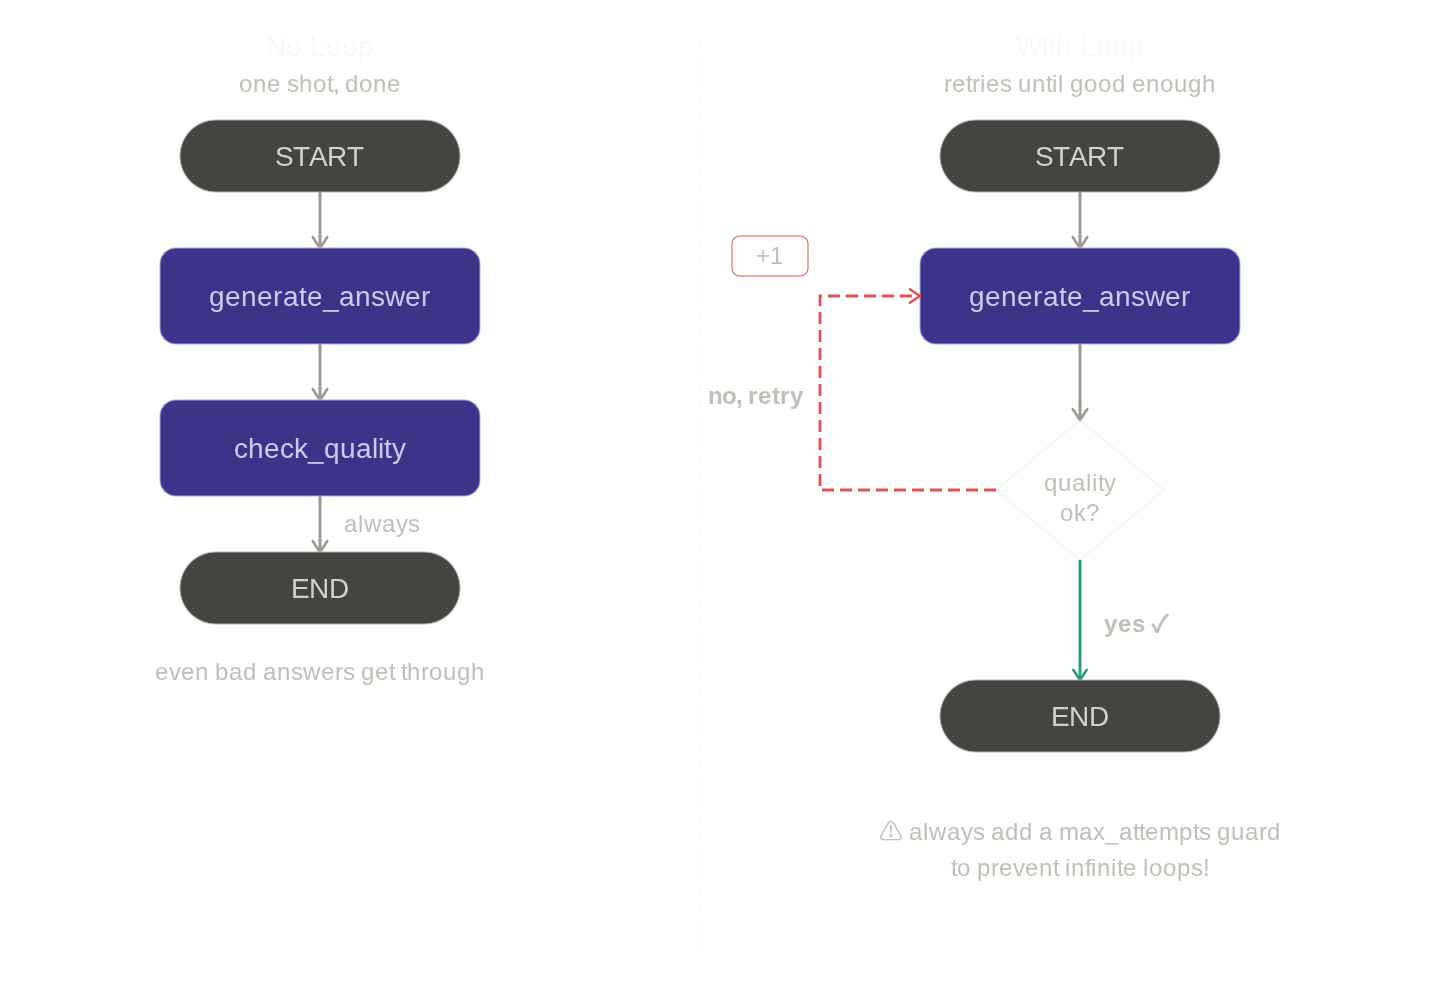

## 5. How Loops Work — The Key Idea
A loop in LangGraph is just a conditional edge that points backwards:



```
# This is all a loop is — a conditional edge that can go BACK
builder.add_conditional_edges(
    "check_quality",      # FROM this node
    should_retry,         # router function
    {
        "retry": "generate_answer",  # ← points BACK to earlier node
        "done":  END                 # ← exits the graph
    }
)
```



In [1]:
!pip install -q langgraph Typing langchain_openai langchain_core

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.5 MB/s eta 0:00:00


In [2]:
from google.colab import userdata
api_key = userdata.get('api_key')

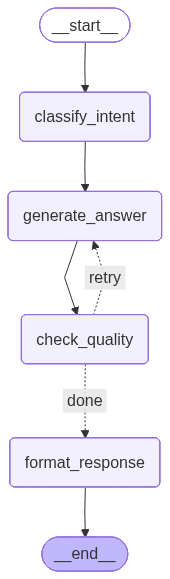

In [3]:
import os
from typing import TypedDict, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


os.environ["OPENAI_API_KEY"] = api_key
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

# ── 1. State — now tracks attempt count ──────────────────
class SupportState(TypedDict):
    user_message: str
    intent:       str
    response:     str
    messages:     Annotated[list, add_messages]
    # NEW: track how many times we've tried
    attempts:     int
    # NEW: feedback from the quality checker to guide retries
    feedback:     str


# ── 2. Classify node (same as before) ────────────────────
def classify_intent(state: SupportState) -> dict:
    prompt = f"""Classify into one word: BILLING, TECHNICAL, or GENERAL.
Message: {state['user_message']}"""
    result = llm.invoke(prompt)
    intent = result.content.strip().upper()
    print(f"  [classify] intent = {intent}")
    return {"intent": intent}

# ── 3. Generate node — now aware of feedback ─────────────
def generate_answer(state: SupportState) -> dict:
    """
    NEW: if feedback exists (from a previous failed attempt),
    include it so the LLM knows what to improve.
    """
    attempt_num = state["attempts"] + 1   # human-readable count
    print(f"  [generate] attempt #{attempt_num}")

    # Build prompt — include feedback if this is a retry
    feedback_section = ""
    if state["feedback"]:
        feedback_section = f"\nPrevious attempt was rejected. Reason: {state['feedback']}\nPlease fix this in your response."

    prompt = f"""You are a helpful support agent. Message type: {state['intent']}
Customer message: {state['user_message']}
{feedback_section}
Write a helpful, specific reply of at least 3 sentences."""

    result = llm.invoke(prompt)

    return {
        "response": result.content,
        "attempts": attempt_num,          # increment the counter
        "messages": [AIMessage(content=result.content)],
    }

# ── 4. NEW: Quality checker node ─────────────────────────
def check_quality(state: SupportState) -> dict:
    """
    Evaluates the response and sets feedback if it's not good enough.
    The router reads state['feedback'] to decide whether to retry.
    """
    response = state["response"]

    # Simple rule-based quality check
    # (you could also use an LLM as the judge here)
    issues = []

    if len(response.split()) < 20:
        issues.append("response is too short — needs more detail")

    if not any(word in response.lower() for word in
               ["please", "sorry", "thank", "help", "can", "will", "let"]):
        issues.append("response sounds robotic — needs a friendlier tone")

    if "?" not in response:
        issues.append("no follow-up question asked — should engage the customer")

    if issues:
        feedback = "; ".join(issues)
        print(f"  [quality] ✗ failed — {feedback}")
        return {"feedback": feedback}
    else:
        print(f"  [quality] ✓ passed after {state['attempts']} attempt(s)")
        return {"feedback": ""}   # empty feedback = passed


# ── 5. Format node (same as before) ──────────────────────
def format_response(state: SupportState) -> dict:
    sign_offs = {
        "BILLING":   "— Billing Team",
        "TECHNICAL": "— Tech Support",
        "GENERAL":   "— Support Team",
    }
    sign_off  = sign_offs.get(state["intent"], "— Support Team")
    formatted = f"{state['response']}\n\n{sign_off}"
    return {"response": formatted}

# ── 6. NEW: Router function for the loop ─────────────────
def should_retry(state: SupportState) -> str:
    """
    The exit condition for the loop.
    Returns 'retry' to loop back, or 'done' to exit.
    Always exits after 3 attempts — NEVER loop without a max guard!
    """
    if state["feedback"] == "":
        return "done"                   # quality passed → exit
    elif state["attempts"] >= 3:
        print(f"  [retry] max attempts reached — exiting anyway")
        return "done"                   # max attempts hit → force exit
    else:
        return "retry"                  # quality failed → loop back

# ── 7. Build the graph ────────────────────────────────────
builder = StateGraph(SupportState)

builder.add_node("classify_intent", classify_intent)
builder.add_node("generate_answer", generate_answer)
builder.add_node("check_quality",   check_quality)   # NEW
builder.add_node("format_response", format_response)

# Forward edges
builder.add_edge(START,             "classify_intent")
builder.add_edge("classify_intent", "generate_answer")
builder.add_edge("generate_answer", "check_quality")  # NEW

# NEW: Conditional edge with loop-back
builder.add_conditional_edges(
    "check_quality",     # from quality checker
    should_retry,        # router decides retry or done
    {
        "retry": "generate_answer",  # ← loop back!
        "done":  "format_response",  # ← move forward
    }
)

builder.add_edge("format_response", END)

app = builder.compile()


# ── 8. Visualize ──────────────────────────────────────────
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

# ── 9. Run it ─────────────────────────────────────────────
def run(msg):
    print(f"\nUser: {msg}")
    print("─" * 40)
    result = app.invoke({
        "user_message": msg,
        "intent":       "",
        "response":     "",
        "messages":     [HumanMessage(content=msg)],
        "attempts":     0,      # NEW: start at zero
        "feedback":     "",     # NEW: start with no feedback
    })
    print(f"\nFinal response (after {result['attempts']} attempt(s)):")
    print(result["response"])

In [4]:
run("I was charged twice for my subscription!")


User: I was charged twice for my subscription!
────────────────────────────────────────
  [classify] intent = BILLING
  [generate] attempt #1
  [quality] ✓ passed after 1 attempt(s)

Final response (after 1 attempt(s)):
Thank you for reaching out regarding the double charge on your subscription. I understand how concerning this can be, and I’m here to help resolve the issue. Could you please provide me with the date of the charges and any relevant transaction details? This will allow me to investigate further and ensure that any discrepancies are addressed promptly.

— Billing Team


## Golden Rule of LOOPS

In [ ]:
# ALWAYS add a max attempts guard — without it you risk
# an infinite loop that burns your API credits!

def should_retry(state) -> str:
    if state["feedback"] == "":
        return "done"             # quality passed
    elif state["attempts"] >= 3:  # ← THIS LINE IS CRITICAL
        return "done"             # force exit after 3 tries
    else:
        return "retry"            # loop back

## Key takeaways

A loop = a conditional edge that points BACKWARDS </br>
Exit condition = a router that returns "done" at some point

Pattern every loop needs:
  1. A counter in state         (attempts: int)
  2. A feedback field in state  (feedback: str)
  3. A quality/check node       (sets feedback)
  4. A router with a max guard  (never loops forever)
  5. A conditional edge back    (points to earlier node)

Loop path:  generate → check → (fail) → generate → check → (pass) → format